# Notebook 2: `Pipeline` + `GridSearchCV` y evaluación de modelos (Etapa 2)

Notebook ejecutado en **Google Colab**. Contiene lo que pide la Etapa 2:

* división de los datos **antes** del escalado,
* siete modelos, cada uno dentro de un `Pipeline` optimizado con `GridSearchCV` (AUC, 5 pliegues),
* ranking comparativo por AUC y *accuracy*,
* matriz de confusión, curvas ROC y AUC del modelo final,
* exportación del modelo para la API.

**Checkpointing por modelo.** Antes de entrenar cada modelo se busca su archivo de resultados
en Drive (`results/<modelo>.joblib`). Si existe y corresponde a los mismos datos y semilla, se
carga y se salta; si no, se entrena y se guarda **inmediatamente** (primero el modelo, al final
el archivo de resultados, que actúa como marca de «completado»). Así, una desconexión de Colab no
obliga a repetir lo ya entrenado.

La exploración de los datos y la demostración de fuga están en el notebook 1; aquí solo se
recupera la misma partición.

## Datos y partición

`heart.csv` ya está en Drive (notebook 1). La celda siguiente aplica la misma limpieza
(`Cholesterol = 0` y `RestingBP = 0` pasan a `NaN`) y la misma partición estratificada 80/20 con
`random_state=42`, **antes de cualquier imputación o escalado**. Produce los mismos conjuntos que
en el notebook 1: 734 pacientes de entrenamiento y 184 de prueba.

In [ ]:
import os
import json
import time
import hashlib
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.svm import SVC
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (roc_auc_score, accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix,
                             roc_curve, ConfusionMatrixDisplay)

try:
    from IPython.display import display
except ImportError:
    display = print
warnings.filterwarnings("ignore")

try:
    from google.colab import drive
    drive.mount("/content/drive")
    BASE_DIR = Path("/content/drive/MyDrive/Heart_Failure_Prediction")
except ImportError:  # ejecución local
    BASE_DIR = Path(os.environ.get("HF_BASE_DIR", "Heart_Failure_Prediction")).resolve()

# Opciones del checkpointing
FORCE_RETRAIN = False   # True: ignora los checkpoints y reentrena todo
RETRAIN_ONLY = []       # p. ej. ["SVC"]: reentrena solo esos modelos
RANDOM_STATE = 42
CV_FOLDS = 5

DIRS = {d: BASE_DIR / d for d in ["models", "results", "figures", "app", "tests"]}
for d in DIRS.values():
    d.mkdir(parents=True, exist_ok=True)

# Datos
DATA_PATH = BASE_DIR / "heart.csv"
DATA_HASH = hashlib.md5(DATA_PATH.read_bytes()).hexdigest()
df = pd.read_csv(DATA_PATH)
TARGET = next(c for c in ["HeartDisease", "target"] if c in df.columns)
for col in ["RestingBP", "Cholesterol"]:
    if col in df.columns:
        df.loc[df[col] == 0, col] = np.nan

X = df.drop(columns=TARGET)
y = df[TARGET].astype(int)

# División ANTES de cualquier imputación o escalado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
CV = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

## Etapa 1 y 2: modelos en `Pipeline` + `GridSearchCV` (con checkpointing)

Funciones reutilizables: `build_preprocessor`, `train_pipeline`, `evaluate`.
Modelos: LogisticRegression, KNN, SVC, GaussianNB, RandomForest,
GradientBoosting y (si está instalado) XGBoost.

In [ ]:
def build_preprocessor(X_ref):
    """Imputación + MinMaxScaler (numéricas) e imputación + OneHot (categóricas)."""
    num_cols = X_ref.select_dtypes(include="number").columns.tolist()
    cat_cols = [c for c in X_ref.columns if c not in num_cols]
    num = Pipeline([("imputer", SimpleImputer(strategy="median")),
                    ("scaler", MinMaxScaler())])
    cat = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore"))])
    # sparse_threshold=0 -> salida densa (GaussianNB no acepta matrices dispersas)
    return ColumnTransformer([("num", num, num_cols), ("cat", cat, cat_cols)],
                             sparse_threshold=0)


def train_pipeline(X_train, y_train, model, param_grid):
    """Pipeline(preprocesamiento + modelo) optimizado con GridSearchCV (AUC)."""
    pipe = Pipeline([("prep", build_preprocessor(X_train)), ("clf", model)])
    grid = GridSearchCV(pipe, param_grid, cv=CV, scoring="roc_auc", n_jobs=-1)
    grid.fit(X_train, y_train)
    return grid


def evaluate(estimator, X_test, y_test):
    """Métricas en test (umbral 0.5) y probabilidades de la clase positiva."""
    proba = estimator.predict_proba(X_test)[:, 1]
    pred = estimator.predict(X_test)
    return {
        "auc": float(roc_auc_score(y_test, proba)),
        "accuracy": float(accuracy_score(y_test, pred)),
        "precision": float(precision_score(y_test, pred, zero_division=0)),
        "recall": float(recall_score(y_test, pred, zero_division=0)),
        "f1": float(f1_score(y_test, pred, zero_division=0)),
        "confusion_matrix": confusion_matrix(y_test, pred).tolist(),
        "y_proba": proba,
    }

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier


def get_model_zoo():
    zoo = {
        "Logistic_Reg": (
            LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
            {"clf__C": [0.01, 0.1, 1, 10, 100]}),
        "KNN": (
            KNeighborsClassifier(),
            {"clf__n_neighbors": [3, 5, 7, 9, 15],
             "clf__weights": ["uniform", "distance"]}),
        "SVC": (
            SVC(probability=True, random_state=RANDOM_STATE),
            {"clf__C": [0.1, 1, 10], "clf__gamma": ["scale", 0.01, 0.1]}),
        "Naive_Bayes": (
            GaussianNB(),
            {"clf__var_smoothing": [1e-9, 1e-7, 1e-5, 1e-3]}),
        "Random_Forest": (
            RandomForestClassifier(random_state=RANDOM_STATE),
            {"clf__n_estimators": [100, 300],
             "clf__max_depth": [None, 5, 10],
             "clf__min_samples_leaf": [1, 3]}),
        "Gradient_Boosting": (
            GradientBoostingClassifier(random_state=RANDOM_STATE),
            {"clf__n_estimators": [100, 200],
             "clf__learning_rate": [0.05, 0.1],
             "clf__max_depth": [2, 3]}),
    }
    try:
        from xgboost import XGBClassifier
        zoo["XGBoost"] = (
            XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss"),
            {"clf__n_estimators": [100, 300], "clf__max_depth": [2, 3, 4],
             "clf__learning_rate": [0.05, 0.1]})
    except ImportError:
        print("xgboost no está instalado: se omite ese modelo.")
    return zoo


MODEL_ZOO = get_model_zoo()
print("Modelos:", list(MODEL_ZOO))

Modelos: ['Logistic_Reg', 'KNN', 'SVC', 'Naive_Bayes', 'Random_Forest', 'Gradient_Boosting', 'XGBoost']


### Bucle de entrenamiento con checkpoint por modelo

* **Existe `results/<modelo>.joblib`** (y es válido para estos datos y esta
  semilla) → se carga y se salta.
* **No existe** → se entrena, se guarda primero el modelo (`models/<modelo>.joblib`)
  y **al final** el archivo de resultados, que actúa como marca de «completado».
  Ambas escrituras son atómicas (archivo temporal + `os.replace`), así una
  desconexión a mitad de escritura no deja un checkpoint corrupto.

In [ ]:
def save_atomic(obj, path):
    path = Path(path)
    tmp = path.with_name(path.name + ".tmp")
    joblib.dump(obj, tmp)
    os.replace(tmp, path)


def result_path(name):
    return DIRS["results"] / f"{name}.joblib"


def model_path(name):
    return DIRS["models"] / f"{name}.joblib"


def load_checkpoint(name):
    """Devuelve el resultado guardado de `name` o None si hay que entrenarlo."""
    if FORCE_RETRAIN or name in RETRAIN_ONLY:
        return None
    if not (result_path(name).exists() and model_path(name).exists()):
        return None
    try:
        res = joblib.load(result_path(name))
    except Exception as e:
        print(f"  checkpoint de {name} ilegible ({e!r}); se reentrena")
        return None
    if res.get("data_hash") != DATA_HASH or res.get("random_state") != RANDOM_STATE:
        print(f"  checkpoint de {name} es de otros datos/semilla; se reentrena")
        return None
    return res


results = {}
for name, (estimator, param_grid) in MODEL_ZOO.items():
    res = load_checkpoint(name)
    if res is not None:
        print(f"[SKIP ] {name}: cargado de Drive ({res['saved_at']}) | "
              f"AUC test = {res['metrics']['auc']:.4f}")
    else:
        print(f"[TRAIN] {name} ...", flush=True)
        t0 = time.time()
        grid = train_pipeline(X_train, y_train, estimator, param_grid)
        fit_time = time.time() - t0
        res = {
            "name": name,
            "best_params": grid.best_params_,
            "best_cv_auc": float(grid.best_score_),
            "metrics": evaluate(grid.best_estimator_, X_test, y_test),
            "fit_time_s": float(fit_time),
            "cv_results": pd.DataFrame(grid.cv_results_)[
                ["params", "mean_test_score", "std_test_score", "rank_test_score"]],
            "data_hash": DATA_HASH,
            "random_state": RANDOM_STATE,
            "saved_at": time.strftime("%Y-%m-%d %H:%M:%S"),
        }
        save_atomic(grid.best_estimator_, model_path(name))   # 1) modelo
        save_atomic(res, result_path(name))                   # 2) resultados (commit)
        print(f"[SAVED] {name}: {fit_time:.1f}s | CV AUC = {res['best_cv_auc']:.4f} | "
              f"AUC test = {res['metrics']['auc']:.4f} -> Drive")
    results[name] = res

print("\nListo:", len(results), "modelos disponibles")

[TRAIN] Logistic_Reg ...
[SAVED] Logistic_Reg: 3.2s | CV AUC = 0.9227 | AUC test = 0.9309 -> Drive
[TRAIN] KNN ...
[SAVED] KNN: 1.3s | CV AUC = 0.9103 | AUC test = 0.9313 -> Drive
[TRAIN] SVC ...
[SAVED] SVC: 3.9s | CV AUC = 0.9194 | AUC test = 0.9143 -> Drive
[TRAIN] Naive_Bayes ...
[SAVED] Naive_Bayes: 1.0s | CV AUC = 0.9088 | AUC test = 0.9073 -> Drive
[TRAIN] Random_Forest ...
[SAVED] Random_Forest: 27.8s | CV AUC = 0.9317 | AUC test = 0.9290 -> Drive
[TRAIN] Gradient_Boosting ...
[SAVED] Gradient_Boosting: 13.9s | CV AUC = 0.9270 | AUC test = 0.9287 -> Drive
[TRAIN] XGBoost ...
[SAVED] XGBoost: 7.2s | CV AUC = 0.9306 | AUC test = 0.9232 -> Drive

Listo: 7 modelos disponibles


## Ranking comparativo (AUC y Accuracy)

El **modelo final se elige por AUC de validación cruzada** (`CV_AUC`), no por
AUC en test: usar test para elegir lo contaminaría como estimación honesta.

In [ ]:
rows = {}
for n, r in results.items():
    m = r["metrics"]
    rows[n] = {"CV_AUC": r["best_cv_auc"], "Test_AUC": m["auc"],
               "Accuracy": m["accuracy"], "Precision": m["precision"],
               "Recall": m["recall"], "F1": m["f1"], "Fit_time_s": r["fit_time_s"]}
ranking = pd.DataFrame(rows).T
ranking["Rank_Test_AUC"] = ranking["Test_AUC"].rank(ascending=False).astype(int)
ranking["Rank_Accuracy"] = ranking["Accuracy"].rank(ascending=False).astype(int)
ranking = ranking.sort_values("Test_AUC", ascending=False)
ranking.round(4).to_csv(DIRS["results"] / "ranking.csv")
display(ranking.round(4))

best_name = ranking["CV_AUC"].astype(float).idxmax()
print(f"Modelo final (mayor AUC en validación cruzada): {best_name}")
print("Mejores hiperparámetros:", results[best_name]["best_params"])

,CV_AUC,Test_AUC,Accuracy,Precision,Recall,F1,Fit_time_s,Rank_Test_AUC,Rank_Accuracy
KNN,0.9103,0.9313,0.8913,0.8868,0.9216,0.9038,1.2824,1,2
Logistic_Reg,0.9227,0.9309,0.8967,0.8879,0.9314,0.9091,3.2072,2,1
Random_Forest,0.9317,0.9290,0.8804,0.8704,0.9216,0.8952,27.7601,3,4
Gradient_Boosting,0.9270,0.9287,0.8859,0.8857,0.9118,0.8986,13.8844,4,3
XGBoost,0.9306,0.9232,0.8696,0.8900,0.8725,0.8812,7.1854,5,5
SVC,0.9194,0.9143,0.8152,0.8036,0.8824,0.8411,3.9143,6,7
Naive_Bayes,0.9088,0.9073,0.8696,0.8900,0.8725,0.8812,0.9662,7,5


Modelo final (mayor AUC en validación cruzada): Random_Forest
Mejores hiperparámetros: {'clf__max_depth': None, 'clf__min_samples_leaf': 3, 'clf__n_estimators': 100}


### Lectura del ranking

| Modelo | AUC (CV) | AUC (prueba) | Accuracy | Recall |
|---|---|---|---|---|
| Random Forest | **0.9317** | 0.9290 | 0.8804 | 0.9216 |
| XGBoost | 0.9306 | 0.9232 | 0.8696 | 0.8725 |
| Gradient Boosting | 0.9270 | 0.9287 | 0.8859 | 0.9118 |
| Regresión logística | 0.9227 | 0.9309 | **0.8967** | **0.9314** |
| SVC | 0.9194 | 0.9143 | 0.8152 | 0.8824 |
| KNN | 0.9103 | **0.9313** | 0.8913 | 0.9216 |
| Naive Bayes | 0.9088 | 0.9073 | 0.8696 | 0.8725 |

* **El modelo final se eligió por AUC de validación cruzada**, no por AUC en prueba: usar la
  prueba para elegir contaminaría la estimación final. Por ese criterio ganó **Random Forest**
  (`max_depth=None`, `min_samples_leaf=3`, `n_estimators=100`).
* En prueba, KNN (0.9313), regresión logística (0.9309), Random Forest (0.9290) y Gradient
  Boosting (0.9287) quedan separados por menos de 0.003 de AUC. Con 184 pacientes de prueba esa
  diferencia no permite declarar un ganador claro: con esta muestra los cuatro son indistinguibles.
* La regresión logística tiene la mejor *accuracy* y el mejor *recall* en prueba, con un modelo
  mucho más simple. Se mantiene Random Forest por haber aplicado el criterio fijado de antemano.
* SVC y Naive Bayes tienen los AUC de prueba más bajos (0.9143 y 0.9073), y SVC además la
  *accuracy* más baja (0.8152).

## Etapa 2: evaluación (matriz de confusión, curva ROC y AUC)

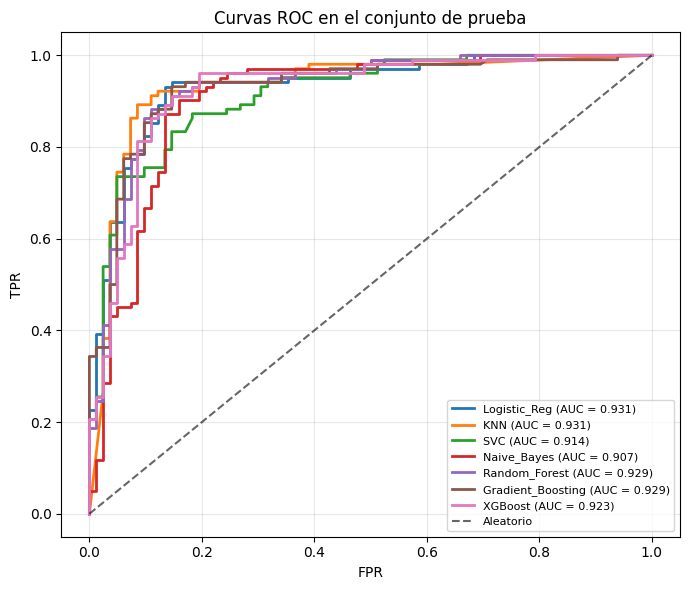

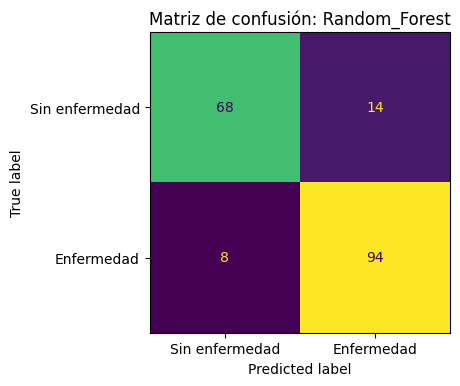

In [ ]:
# Curvas ROC de todos los modelos (desde los checkpoints, sin reentrenar)
fig, ax = plt.subplots(figsize=(7, 6))
for n, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r["metrics"]["y_proba"])
    ax.plot(fpr, tpr, lw=2, label=f"{n} (AUC = {r['metrics']['auc']:.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.6, label="Aleatorio")
ax.set_xlabel("FPR")
ax.set_ylabel("TPR")
ax.set_title("Curvas ROC en el conjunto de prueba")
ax.legend(loc="lower right", fontsize=8)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(DIRS["figures"] / "roc_all_models.png", dpi=150)
plt.show()

# Matriz de confusión del modelo final
cm = np.array(results[best_name]["metrics"]["confusion_matrix"])
fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay(cm, display_labels=["Sin enfermedad", "Enfermedad"]).plot(
    ax=ax, colorbar=False)
ax.set_title(f"Matriz de confusión: {best_name}")
fig.tight_layout()
fig.savefig(DIRS["figures"] / f"confusion_{best_name}.png", dpi=150)
plt.show()

### Lectura de la evaluación del modelo final

Matriz de confusión de Random Forest sobre los 184 pacientes de prueba:

| | Predicho sin enfermedad | Predicho con enfermedad |
|---|---|---|
| **Real sin enfermedad** | 68 (VN) | 14 (FP) |
| **Real con enfermedad** | 8 (FN) | 94 (VP) |

* *Accuracy* = (68 + 94) / 184 = 0.880; *recall* = 94 / 102 = 0.922; *precision* = 94 / 108 = 0.870.
* Hay **8 pacientes con enfermedad clasificados como sanos** (7.8 % de los 102 enfermos). En un
  problema clínico ese es el error más costoso. El umbral de 0.5 es el que usa `predict`;
  bajarlo aumentaría el *recall* a costa de más falsos positivos. No se modificó el umbral en
  este proyecto.
* Las curvas ROC de los siete modelos quedan muy próximas entre sí, coherente con los AUC de la
  tabla anterior.

## Exportar el modelo final y archivos de despliegue

Se guarda `model.joblib` (raíz y `app/`), `app/features.json` y un ejemplo de
entrada para las pruebas. **Nota:** el pipeline incluye un `ColumnTransformer`
que trabaja con nombres de columna, por eso la API recibe un diccionario
`{columna: valor}` y no una lista de números como en el ejemplo del enunciado.

In [ ]:
import sklearn

final_pipe = joblib.load(model_path(best_name))
joblib.dump(final_pipe, BASE_DIR / "model.joblib")
joblib.dump(final_pipe, DIRS["app"] / "model.joblib")

meta = {"features": X.columns.tolist(), "target": TARGET, "model": best_name,
        "sklearn_version": sklearn.__version__}
(DIRS["app"] / "features.json").write_text(json.dumps(meta, indent=2))

sample = json.loads(X_test.iloc[[0]].to_json(orient="records"))[0]
(DIRS["tests"] / "sample_input.json").write_text(json.dumps(sample, indent=2))
print("Modelo exportado:", best_name)
print("Ejemplo de entrada:", sample)

Modelo exportado: Random_Forest
Ejemplo de entrada: {'Age': 46, 'Sex': 'M', 'ChestPainType': 'ASY', 'RestingBP': 115.0, 'Cholesterol': None, 'FastingBS': 0, 'RestingECG': 'Normal', 'MaxHR': 113, 'ExerciseAngina': 'Y', 'Oldpeak': 1.5, 'ST_Slope': 'Flat'}


El modelo final se guardó en `model.joblib` y `app/model.joblib`, junto con `app/features.json`
(columnas esperadas) y `tests/sample_input.json` (un paciente de ejemplo con `Cholesterol` nulo,
que el `Pipeline` imputa con la mediana de entrenamiento). Estos archivos se usan en las Etapas
3 a 5.